# 1. Sentiment Classification

In [ ]:
# Install required packages
# !pip install numpy pandas nltk scikit-learn matplotlib seaborn wordcloud gensim

# Download NLTK data
import nltk

nltk.download("movie_reviews")
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download("averaged_perceptron_tagger")
nltk.download("punkt_tab")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\ngovi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ngovi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ngovi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ngovi\AppData\Roaming\nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\ngovi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ngovi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

In [4]:
# Load movie reviews dataset

from nltk.corpus import movie_reviews

file_ids = movie_reviews.fileids()
movie_reviews_dict = {"label": [], "text": [], "length": []}
for file_id in file_ids:
    movie_reviews_dict["label"].append(file_id)
    movie_reviews_dict["text"].append(movie_reviews.raw(file_id))
    movie_reviews_dict["length"].append(len(movie_reviews.raw(file_id)))

df = pd.DataFrame.from_dict(movie_reviews_dict)
df = df.sample(frac=1).reset_index(drop=True)

# Map labels to sentiment (pos/neg)
df["sentiment"] = df["label"].apply(lambda x: "positive" if "pos" in x else "negative")

print("---------------- INFO ----------------")
display(df.info())
print("---------------- DESCRIBE ----------------")
display(df.describe())

---------------- INFO ----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      2000 non-null   object
 1   text       2000 non-null   object
 2   length     2000 non-null   int64 
 3   sentiment  2000 non-null   object
dtypes: int64(1), object(3)
memory usage: 62.6+ KB


None

---------------- DESCRIBE ----------------


,length
count,2000.000000
mean,3893.002000
std,1712.425852
min,91.000000
25%,2737.750000
50%,3622.500000
75%,4720.250000
max,14957.000000


### Text Preprocessing

In [5]:
# Text Preprocessing

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
import re
import string

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()


def preprocess_text(text):
    """
    Advanced preprocessing: + lemmatization, remove numbers/special chars

    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text (space-separated tokens)
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove numbers and special characters (keep only letters and spaces)
    text = re.sub(r"[^a-z\s]", "", text)

    # 3. Tokenize
    tokens = word_tokenize(text)

    # 4. Remove stopwords
    tokens = [t for t in tokens if t not in stop_words]

    # 5. Lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

In [6]:
# Test preprocessing function
sample_text = "This movie is AMAZING!!! I've watched it 3 times. Best film of 2023! :)"

print("Original:", sample_text)
print("Preprocessed:", preprocess_text(sample_text))

Original: This movie is AMAZING!!! I've watched it 3 times. Best film of 2023! :)
Preprocessed: movie amazing ive watched time best film


In [7]:
# Applying advanced preprocessing
df["processed_text"] = df["text"].apply(preprocess_text)
print("\nDataFrame after applying preprocessing:")
display(df.head())


DataFrame after applying preprocessing:


,label,text,length,sentiment,processed_text
0,pos/cv860_13853.txt,the verdict : spine-chilling drama from horror...,4961,positive,verdict spinechilling drama horror maestro ste...
1,neg/cv353_19197.txt,""" the 44 caliber killer has struck again . "" ...",4303,negative,caliber killer struck starring john leguizamo ...
2,pos/cv333_8916.txt,in the company of men made a splash at the sun...,5742,positive,company men made splash sundance film festival...
3,neg/cv905_28965.txt,"in the year 2029 , captain leo davidson ( mark...",3566,negative,year captain leo davidson mark wahlberg boogie...
4,pos/cv289_6463.txt,[note that followups are directed to rec . art...,3923,positive,note followup directed rec art movie currentfi...


In [8]:
# Split data into train/test sets
from sklearn.model_selection import train_test_split

X = df["processed_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTrain/Test Split:")
print(f"\nX_train shape: {X_train.shape}")
print(f"\nX_test shape: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")


Train/Test Split:

X_train shape: (1600,)

X_test shape: (400,)

y_train distribution:
sentiment
positive    800
negative    800
Name: count, dtype: int64

y_test distribution:
sentiment
negative    200
positive    200
Name: count, dtype: int64


### Extracting Features

In [9]:
# Feature Extraction Method 1 - Bag of Words
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report


# Encode labels
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

pipeline = Pipeline(
    [("vectorizer", CountVectorizer()), ("clf", LogisticRegression(max_iter=1000))]
)

param_grid = {
    "vectorizer__max_features": [2000, 5000, 8000],
    "vectorizer__min_df": [1, 2],
    "vectorizer__max_df": [0.95, 0.9],
}

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train_enc)

print("Bag of Words:")
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV accuracy:")
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nTest accuracy:")
print(accuracy_score(y_test_enc, y_pred))

print("\nClassification report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

best_vectorizer = best_model.named_steps["vectorizer"]
print("Best vocabulary size:", len(best_vectorizer.get_feature_names_out()))

bow_vectorizer = CountVectorizer(max_features=8000, min_df=2, max_df=0.99)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Bag of Words:
Best parameters:
{'vectorizer__max_df': 0.95, 'vectorizer__max_features': 8000, 'vectorizer__min_df': 1}

Best CV accuracy:
0.8200000000000001

Test accuracy:
0.83

Classification report:
              precision    recall  f1-score   support

    negative       0.82      0.84      0.83       200
    positive       0.84      0.81      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400

Best vocabulary size: 8000


In [10]:
# Feature Extraction Method 2 - TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

pipeline = Pipeline(
    [("vectorizer", TfidfVectorizer()), ("clf", LogisticRegression(max_iter=1000))]
)


grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train_enc)

print("TF-IDF:")
print("Best parameters:")
print(grid.best_params_)

print("\nBest CV accuracy:")
print(grid.best_score_)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("\nTest accuracy:")
print(accuracy_score(y_test_enc, y_pred))

print("\nClassification report:")
print(classification_report(y_test_enc, y_pred, target_names=le.classes_))

best_vectorizer = best_model.named_steps["vectorizer"]
print("Best vocabulary size:", len(best_vectorizer.get_feature_names_out()))

tfidf_vectorizer = TfidfVectorizer(max_features=2000, min_df=2, max_df=0.9)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
TF-IDF:
Best parameters:
{'vectorizer__max_df': 0.95, 'vectorizer__max_features': 2000, 'vectorizer__min_df': 2}

Best CV accuracy:
0.8256250000000002

Test accuracy:
0.8375

Classification report:
              precision    recall  f1-score   support

    negative       0.82      0.87      0.84       200
    positive       0.86      0.81      0.83       200

    accuracy                           0.84       400
   macro avg       0.84      0.84      0.84       400
weighted avg       0.84      0.84      0.84       400

Best vocabulary size: 2000


### Find Best Model

In [11]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import time

def train_and_evaluate(
    model, X_train, X_test, y_train, y_test, model_name, feature_name
):
    """
    Train a model and return evaluation metrics

    Args:
        model: sklearn classifier
        X_train, X_test: feature matrices
        y_train, y_test: labels
        model_name: name of the model (str)
        feature_name: name of feature type (str)

    Returns:
        dict: Dictionary containing all metrics
    """

    # -------------------- Training --------------------
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # -------------------- Prediction --------------------
    y_pred = model.predict(X_test)

    # -------------------- Metrics --------------------
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    # -------------------- Results --------------------
    return {
        "Model": model_name,
        "Feature_Type": feature_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1_Score": f1,
        "Training_Time_sec": train_time,
    }

In [12]:
# Train all models on all feature types

results = []

models = {
    "Multinomial NB": MultinomialNB(),
    "Bernoulli NB": BernoulliNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

feature_sets = {
    "Bag-of-Words": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf),
}

# Loop through all combinations of models and features
# Use train_and_evaluate function
# Append results to list

# Convert results to DataFrame for easy analysis
# results_df = pd.DataFrame(results)

# Train all models on all feature types
results = []

for feature_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        result = train_and_evaluate(
            model=model,
            X_train=Xtr,
            X_test=Xte,
            y_train=y_train_enc,
            y_test=y_test_enc,
            model_name=model_name,
            feature_name=feature_name,
        )
        results.append(result)

# Convert results to DataFrame for easy analysis
results_df = pd.DataFrame(results)

In [13]:
# Display comprehensive results table
results_df = results_df.sort_values(by=["F1_Score", "Accuracy"], ascending=False)

display(results_df)

,Model,Feature_Type,Accuracy,Precision,Recall,F1_Score,Training_Time_sec
2,Logistic Regression,Bag-of-Words,0.8375,0.837914,0.8375,0.837450,0.052877
5,Logistic Regression,TF-IDF,0.8375,0.838932,0.8375,0.837328,0.008770
0,Multinomial NB,Bag-of-Words,0.8300,0.836597,0.8300,0.829163,0.001789
3,Multinomial NB,TF-IDF,0.7950,0.800071,0.7950,0.794130,0.001327
4,Bernoulli NB,TF-IDF,0.7950,0.800898,0.7950,0.793991,0.002562
1,Bernoulli NB,Bag-of-Words,0.7900,0.798630,0.7900,0.788472,0.002725


In [14]:
# TODO: Find best models
best_overall = results_df.sort_values("F1_Score", ascending=False).iloc[0]

print("Best overall model:")
display(best_overall)

Best overall model:


Model                Logistic Regression
Feature_Type                Bag-of-Words
Accuracy                          0.8375
Precision                       0.837914
Recall                            0.8375
F1_Score                         0.83745
Training_Time_sec               0.052877
Name: 2, dtype: object

### Confusion Matrix

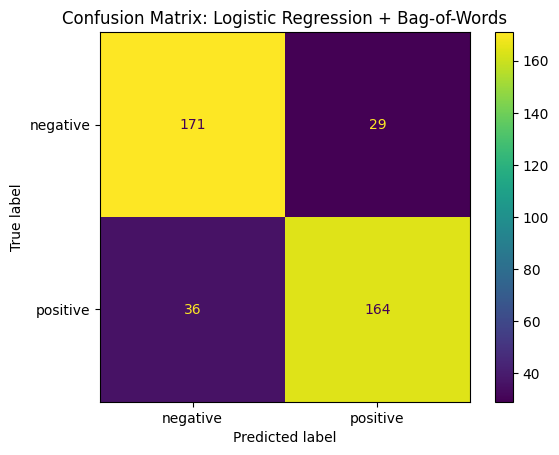

In [15]:
# Display confusion matrix for best model

from sklearn.metrics import ConfusionMatrixDisplay

best_model_name = best_overall["Model"]
best_feature_name = best_overall["Feature_Type"]

# Retrieve best model and features
best_model = models[best_model_name]
Xtr_best, Xte_best = feature_sets[best_feature_name]

# Retrain best model on full training data
best_model.fit(Xtr_best, y_train_enc)
y_pred_best = best_model.predict(Xte_best)

# Confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name} + {best_feature_name}")
plt.show()

### Error Analysis

In [16]:
# Labelling data
test_df = df.loc[X_test.index].copy()

test_df["y_true"] = y_test_enc
test_df["y_pred"] = y_pred_best

test_df["true_label"] = le.inverse_transform(test_df["y_true"])
test_df["pred_label"] = le.inverse_transform(test_df["y_pred"])

test_df["correct"] = test_df["y_true"] == test_df["y_pred"]

display(test_df.head())

,label,text,length,sentiment,processed_text,y_true,y_pred,true_label,pred_label,correct
1469,neg/cv633_29730.txt,""" what's your favorite new york moment ? "" \n...",3329,negative,whats favorite new york moment one climbing ch...,0,0,negative,negative,True
39,neg/cv254_5870.txt,even the best comic actor is at the mercy of h...,3593,negative,even best comic actor mercy material subpar su...,0,0,negative,negative,True
175,pos/cv324_7082.txt,produced by robert lantos & stephen j . roth \...,3939,positive,produced robert lantos stephen j roth directed...,1,1,positive,positive,True
916,neg/cv290_11981.txt,billy crystal reappears in yet another high co...,2385,negative,billy crystal reappears yet another high conce...,0,0,negative,negative,True
972,neg/cv138_13903.txt,my opinion on a film can be easily swayed by t...,6695,negative,opinion film easily swayed presence actor love...,0,0,negative,negative,True


In [17]:
# Find and categorize misclassifications
false_positives = test_df[
    (test_df["pred_label"] == "positive") & (test_df["true_label"] == "negative")
]

false_negatives = test_df[
    (test_df["pred_label"] == "negative") & (test_df["true_label"] == "positive")
]

print("False Positives:", len(false_positives))
display(false_positives.head())
print("False Negatives:", len(false_negatives))
display(false_negatives.head())

False Positives: 29


,label,text,length,sentiment,processed_text,y_true,y_pred,true_label,pred_label,correct
212,neg/cv289_6239.txt,"i've heard it called "" jaws with claws "" and t...",1242,negative,ive heard called jaw claw thats fair summation...,0,1,negative,positive,False
124,neg/cv393_29234.txt,"not so long ago , men by the names of peckinpa...",2912,negative,long ago men name peckinpah ford leone eastwoo...,0,1,negative,positive,False
843,neg/cv865_28796.txt,"one of these days , i'll make good on my promi...",4929,negative,one day ill make good promise never rent anoth...,0,1,negative,positive,False
938,neg/cv333_9443.txt,"as a hot-shot defense attorney , kevin lomax (...",3784,negative,hotshot defense attorney kevin lomax keanu ree...,0,1,negative,positive,False
1289,neg/cv090_0049.txt,various films seen at the seattle film festiva...,7227,negative,various film seen seattle film festival trueth...,0,1,negative,positive,False


False Negatives: 36


,label,text,length,sentiment,processed_text,y_true,y_pred,true_label,pred_label,correct
1061,pos/cv865_2895.txt,"every once in a while , a film sneaks up on me...",4173,positive,every film sneak take completely surprise dont...,1,0,positive,negative,False
1693,pos/cv877_29274.txt,"susan granger's review of "" bread and tulips ""...",1886,positive,susan granger review bread tulip first look pi...,1,0,positive,negative,False
1629,pos/cv603_17694.txt,"in october of 1997 , audiences were dazzled by...",4585,positive,october audience dazzled horror surprise hit k...,1,0,positive,negative,False
261,pos/cv911_20260.txt,"usually when a blockbuster comes out , it's lo...",3477,positive,usually blockbuster come loaded effect star ba...,1,0,positive,negative,False
1276,pos/cv024_6778.txt,"call 911 for the cliche police if you must , b...",5302,positive,call cliche police must eye window soul finest...,1,0,positive,negative,False


In [18]:
# Analyze error patterns
print("Average length (correct):", test_df[test_df["correct"]]["length"].mean())

print("Average length (incorrect):", test_df[~test_df["correct"]]["length"].mean())

from collections import Counter

all_misclassified_text = " ".join(test_df[~test_df["correct"]]["processed_text"])
word_counts = Counter(all_misclassified_text.split())

print("Most common words in misclassified reviews:")
display(word_counts.most_common(10))

Average length (correct): 3920.70447761194
Average length (incorrect): 3856.846153846154
Most common words in misclassified reviews:


[('film', 410),
 ('one', 156),
 ('movie', 155),
 ('like', 124),
 ('character', 107),
 ('get', 105),
 ('good', 96),
 ('time', 90),
 ('scene', 87),
 ('make', 86)]

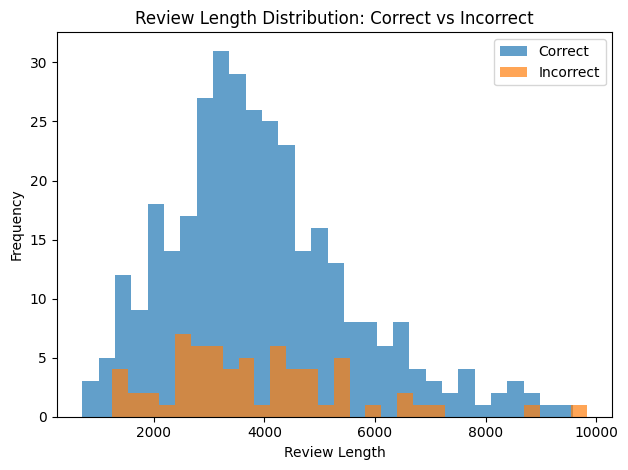

In [19]:
# Visualization - Length distribution
import matplotlib.pyplot as plt

plt.figure()
plt.hist(test_df[test_df["correct"]]["length"], bins=30, alpha=0.7, label="Correct")
plt.hist(test_df[~test_df["correct"]]["length"], bins=30, alpha=0.7, label="Incorrect")

plt.xlabel("Review Length")
plt.ylabel("Frequency")
plt.title("Review Length Distribution: Correct vs Incorrect")
plt.legend()
plt.tight_layout()
plt.show()

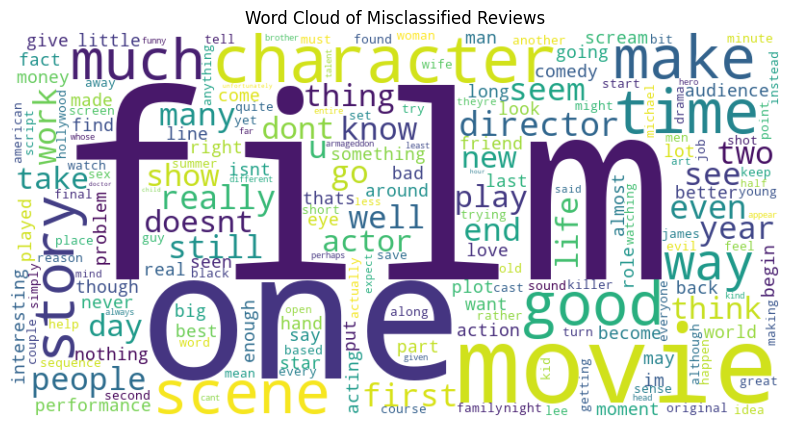

In [20]:
# Visualization - Word cloud of misclassified reviews
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(
    all_misclassified_text
)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Misclassified Reviews")
plt.show()

# 2: Word Vectors & Similarity

### Building dictionary of unique words

In [ ]:
unique_text = set(" ".join(df["processed_text"]).split())

sorted_unique_text = sorted(list(unique_text))
word2id = {word: idx for idx, word in enumerate(sorted_unique_text)}
word2id

{'aa': 0,
 'aaa': 1,
 'aaaaaaaaah': 2,
 'aaaaaaaahhhh': 3,
 'aaaaaah': 4,
 'aaaahhhs': 5,
 'aahs': 6,
 'aaliyah': 7,
 'aaliyahs': 8,
 'aalyah': 9,
 'aalyahs': 10,
 'aameetings': 11,
 'aamir': 12,
 'aardman': 13,
 'aaron': 14,
 'aatish': 15,
 'ab': 16,
 'aback': 17,
 'abandon': 18,
 'abandoned': 19,
 'abandoning': 20,
 'abandonment': 21,
 'abating': 22,
 'abba': 23,
 'abbe': 24,
 'abberation': 25,
 'abberline': 26,
 'abbot': 27,
 'abbott': 28,
 'abbotts': 29,
 'abbreviated': 30,
 'abby': 31,
 'abbys': 32,
 'abc': 33,
 'abdomen': 34,
 'abducted': 35,
 'abductees': 36,
 'abduction': 37,
 'abduljabbar': 38,
 'abe': 39,
 'abel': 40,
 'aberdeen': 41,
 'aberration': 42,
 'abetted': 43,
 'abetting': 44,
 'abeyance': 45,
 'abhorrence': 46,
 'abhorrent': 47,
 'abider': 48,
 'abides': 49,
 'abigail': 50,
 'abigails': 51,
 'abiility': 52,
 'ability': 53,
 'abject': 54,
 'ablaze': 55,
 'able': 56,
 'ably': 57,
 'abnormal': 58,
 'abnormally': 59,
 'aboard': 60,
 'abode': 61,
 'abolish': 62,
 'abolit

In [22]:
co_occurrence_matrix = np.zeros(
    (len(sorted_unique_text), len(sorted_unique_text)), dtype=int
)
co_occurrence_matrix.shape

(41525, 41525)

### Calculating co-occurrence matrix

In [23]:
window_size = 3

# loop through each document
for text in df["processed_text"]:
    tokens = text.split()
    token_ids = [word2id[t] for t in tokens if t in word2id]

    # loop through each token in the document
    for i, token_id in enumerate(token_ids):
        start = max(0, i - window_size)
        end = min(len(token_ids), i + window_size + 1)

        for j in range(start, end):
            ## avoid self-co-occurrence
            if i != j:
                co_occurrence_matrix[token_id, token_ids[j]] += 1

co_occurrence_matrix

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 2]], shape=(41525, 41525))

### Cosine Similarity

In [24]:
## 2: Word Vectors & Similarity
def get_cosine_similarity(vec1, vec2):
    """
    Compute cosine similarity between two vectors

    Args:
        vec1, vec2: numpy arrays

    Returns:
        float: cosine similarity
    """
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)

    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0

    return dot_product / (norm_vec1 * norm_vec2)

In [25]:
# test compare 2 word vectors
word1 = "film"
word2 = "movie"

vec1 = co_occurrence_matrix[word2id[word1]]
vec2 = co_occurrence_matrix[word2id[word2]]

similarity = get_cosine_similarity(vec1, vec2)
similarity

np.float64(0.9540647025398274)

In [26]:
def find_top_similar_words(target_word, top_k=5):
    """
    Find top K similar words to the target word based on cosine similarity

    Args:
        target_word (str): The word to find similarities for
        top_k (int): Number of top similar words to return

    Returns:
        list of tuples: List of (word, similarity) tuples
    """
    if target_word not in word2id:
        return []

    target_vec = co_occurrence_matrix[word2id[target_word]]
    similarities = []

    for word, idx in word2id.items():
        if word != target_word:
            vec = co_occurrence_matrix[idx]
            sim = get_cosine_similarity(target_vec, vec)
            similarities.append((word, sim))

    # Sort by similarity and return top K
    similarities.sort(key=lambda x: x[1], reverse=True)
    return similarities[:top_k]

In [27]:
find_top_similar_words("good")

[('great', np.float64(0.8874149804432769)),
 ('really', np.float64(0.8696160508204859)),
 ('one', np.float64(0.8657208203483295)),
 ('well', np.float64(0.8546574630630656)),
 ('like', np.float64(0.8509553211182169))]

### PPMI (Positive Pointwise Mutual Information)
Indicating how much more often two events co-occur than if they were independent

In [ ]:
import numpy as np
from scipy import sparse

#  co_occurrence_matrix to sparse
C = sparse.csc_matrix(co_occurrence_matrix)

# prepare to calculate PPMI
total_count = C.sum()
row_sums = np.array(C.sum(axis=1)).flatten()
col_sums = np.array(C.sum(axis=0)).flatten()

# zero division prevention
row_sums[row_sums == 0] = 1
col_sums[col_sums == 0] = 1

# calculate PPMI on non-zero entries only
C_coo = C.tocoo()
rows = C_coo.row
cols = C_coo.col
data = C_coo.data

# PMI: log( (Count(w,c) * N) / (Count(w) * Count(c)) )
numerator = data * total_count
denominator = row_sums[rows] * col_sums[cols]
pmi_values = np.log(numerator / denominator)

pmi_values[pmi_values < 0] = 0
ppmi = sparse.coo_matrix(
    (pmi_values, (rows, cols)), 
    shape=C.shape
)


Đã tính xong PPMI!
Kích thước thật: (41525, 41525)
Số lượng phần tử khác 0 được lưu: 2795275


In [34]:
ppmi


<COOrdinate sparse matrix of dtype 'float64'
	with 2795275 stored elements and shape (41525, 41525)>

### PCA

In [37]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
word_vectors_2d = pca.fit_transform(ppmi)

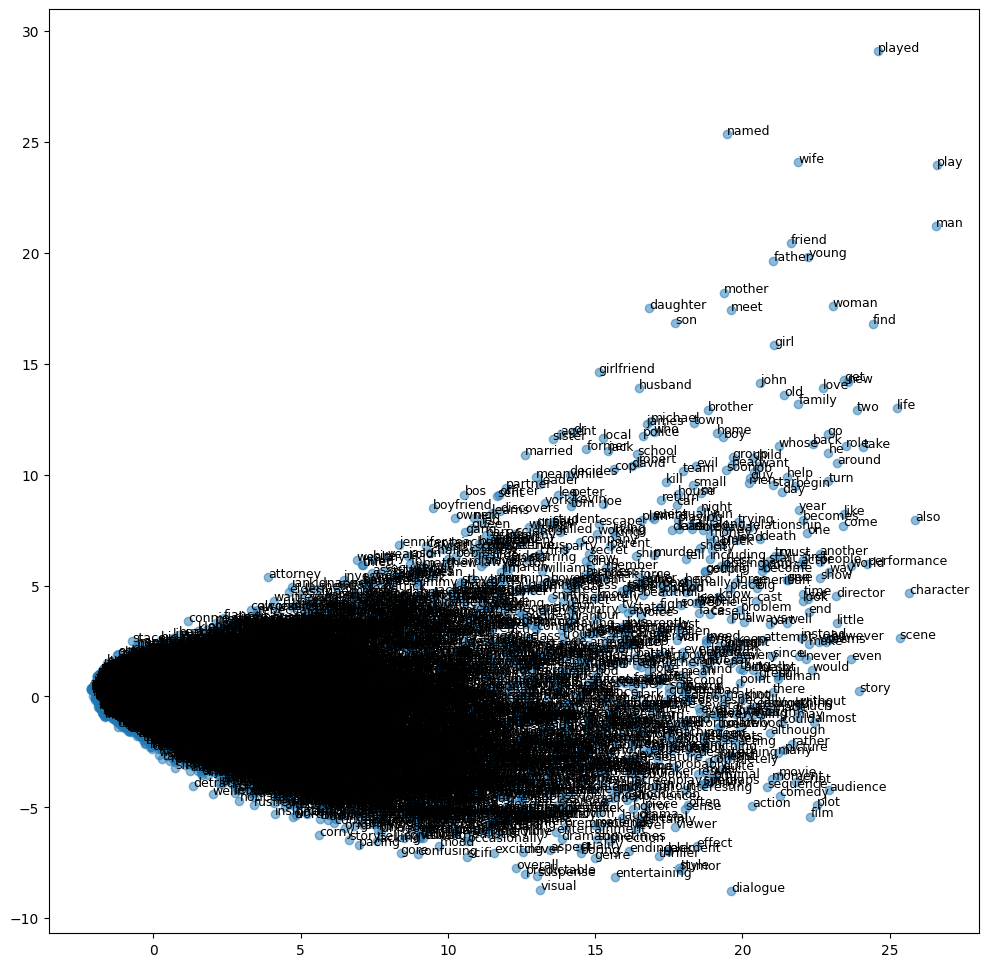

In [38]:
plt.figure(figsize=(12, 12))

plt.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1], alpha=0.5)
for word, index in word2id.items():
    x = word_vectors_2d[index, 0]
    y = word_vectors_2d[index, 1]

    plt.text(x, y, word, fontsize=9)

plt.show()

### Word analogy

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

id2word = {i: w for w, i in word2id.items()}

def word_analogy(word_a, word_b, word_c, word_vector, top_k=5):
    """
    Solve word analogy: word_a - word_b + word_c = ?

    Args:
        word_a, word_b, word_c (str): Input words
        top_k (int): Number of top similar words to return

    Returns:
        list of tuples: List of (word, similarity) tuples
    """
    if word_a not in word2id or word_b not in word2id or word_c not in word2id:
        return []

    vec_a = word_vector[word2id[word_a]]
    vec_b = word_vector[word2id[word_b]]
    vec_c = word_vector[word2id[word_c]]

    target_vec = vec_a - vec_b + vec_c

    similarities = cosine_similarity(target_vec, word_vector).flatten()

    top_indices = np.argsort(similarities)[-top_k - 3 :][::-1]

    results = []
    count = 0
    input_ids = {word2id[word_a], word2id[word_b], word2id[word_c]}

    for idx in top_indices:
        if idx in input_ids:
            continue

        word = id2word[idx]
        score = similarities[idx]
        results.append((word, score))

        count += 1
        if count >= top_k:
            break

    return results

In [53]:
word_analogy("actor", "man", "woman", ppmi.tocsr())

[('performance', np.float64(0.07167401147771815)),
 ('actress', np.float64(0.06452742522434517)),
 ('role', np.float64(0.06443367361842176)),
 ('supporting', np.float64(0.06224815837957179)),
 ('acting', np.float64(0.05776995779837758))]

# 3. Document Search

In [ ]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load Real Dataset (20 Newsgroups)
print("Loading 20 Newsgroups dataset... Please wait.")

categories = [
    "sci.space",  # Space and Astronomy
    "comp.graphics",  # Computer Graphics
    "rec.sport.baseball",  # Baseball
    "sci.med",  # Medicine
]

# Load the dataset
# subset='train': use the training set
# remove=('headers', 'footers', 'quotes'): remove metadata to force the model to look at content only
newsgroups = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes"),
    random_state=42,
)

documents = newsgroups.data
print(f"Loaded {len(documents)} documents.")


# Build TF-IDF Vectors
print("Building TF-IDF matrix...")

# Initialize Vectorizer
# max_features=10000: Limit vocabulary to top 10k words to save memory
vectorizer = TfidfVectorizer(stop_words="english", max_features=10000)

# Create the matrixc converts all text to numbers
tfidf_matrix = vectorizer.fit_transform(documents)

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")


# STEP 3: Search Function
def search(query, top_k=3):
    """
    Search for documents matching the query using Cosine Similarity.

    Args:
        query (str): The search string.
        top_k (int): Number of top results to return.

    Returns:
        list of tuples: (document_content, score)
    """
    # Transform query to vector
    query_vec = vectorizer.transform([query])

    # Calculate cosine similarity against all documents
    # flatten() converts the result from [[s1, s2...]] to [s1, s2...]
    cosine_sim = cosine_similarity(query_vec, tfidf_matrix).flatten()

    # Get indices of top k results
    # argsort sorts ascending, so we take the end ([-top_k:]) and reverse it ([::-1])
    related_docs_indices = cosine_sim.argsort()[-top_k:][::-1]

    results = []
    for idx in related_docs_indices:
        score = cosine_sim[idx]
        if score > 0.05:  # Threshold to filter out irrelevant results
            # Clean up newlines for better display
            content = documents[idx].replace("\n", " ").strip()
            # Truncate content if it's too long (for display purposes)
            preview = content[:200] + "..." if len(content) > 200 else content
            results.append((preview, score))

    if results:
        print(f"Found {len(results)} relevant documents:\n")
        for i, (doc, score) in enumerate(results, 1):
            print(f"{i}. [Score: {score:.4f}]")
            print(f"   Content: {doc}\n")
    else:
        print("No relevant documents found. Try different keywords.")

    return results

Loading 20 Newsgroups dataset... Please wait.
Loaded 2368 documents.
Building TF-IDF matrix...
TF-IDF Matrix Shape: (2368, 10000)


In [51]:
# Test search function
print("\n" + "=" * 40)
print(" Categories: Space, Graphics, Baseball, Medicine")

results = search("nasa mars landing")
# results = search("computer graphics rendering")
# results = search("baseball pitching stats")
# results = search("doctor medicine treatment")



 Categories: Space, Graphics, Baseball, Medicine
Found 3 relevant documents:

1. [Score: 0.3900]
   Content: Are you volunteering? :)   Will NASA have "available landing sites" in the Russian Republic, now that they are Our Friends and Comrades?

2. [Score: 0.2559]
   Content: What is the deal with life on Mars?  I save the "face" and heard  associated theories. (which sound thin to me)  Are we going back to Mars to look at this face agian? Does anyone buy all the life theo...

3. [Score: 0.2189]
   Content: DFW was designed with the STS in mind (which really mean very little).  Much of their early PR material had scenes with a shuttle landing and two or three others pulled up to gates.  I guess they were...

